/tmp/ipykernel_2619033/1730048364.py:166: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.0, 0.08, 1.0, 1.0])


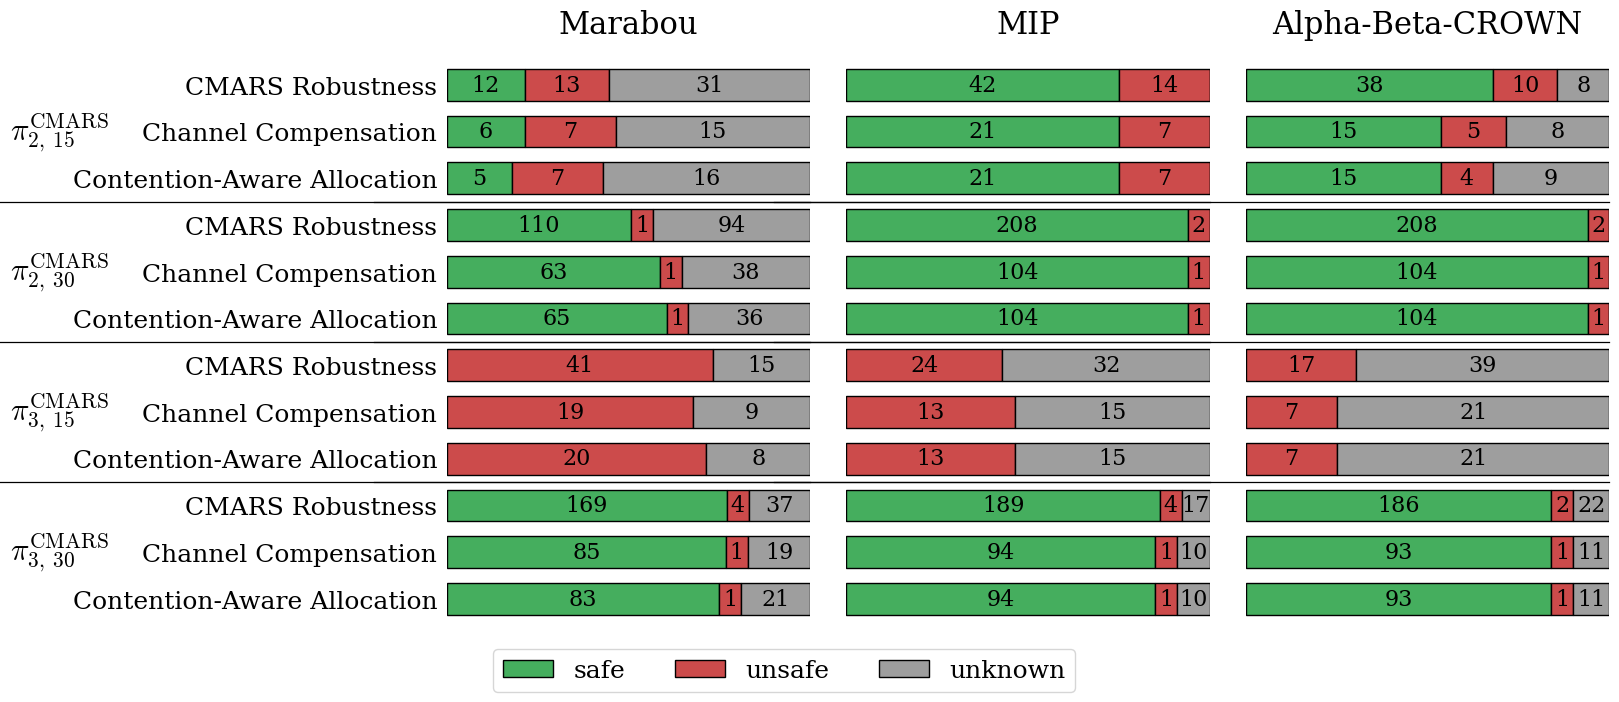

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib as mpl
from matplotlib.patches import Patch

# -------------------- Styling (set BEFORE figure creation) --------------------
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "ytick.labelsize": 18,
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

# -------------------- Data --------------------
architectures = [r"$\pi^{\text{CMARS}}_{2, \; 15}$", r"$\pi^{\text{CMARS}}_{2, \; 30}$", r"$\pi^{\text{CMARS}}_{3, \; 15}$", r"$\pi^{\text{CMARS}}_{3, \; 30}$"]
metrics = ["CMARS Robustness", "Channel Compensation", "Contention-Aware Allocation"]
tools = ["Marabou", "MIP", "Alpha-Beta-CROWN"]

data = {
    (r"$\pi^{\text{CMARS}}_{2, \; 15}$", "CMARS Robustness"): {"Marabou": (12, 13, 31), "MIP": (42, 14, 0), "Alpha-Beta-CROWN": (38, 10, 8)},
    (r"$\pi^{\text{CMARS}}_{2, \; 15}$", "Channel Compensation"): {"Marabou": (6, 7, 15), "MIP": (21, 7, 0), "Alpha-Beta-CROWN": (15, 5, 8)},
    (r"$\pi^{\text{CMARS}}_{2, \; 15}$", "Contention-Aware Allocation"): {"Marabou": (5, 7, 16), "MIP": (21, 7, 0), "Alpha-Beta-CROWN": (15, 4, 9)},
    (r"$\pi^{\text{CMARS}}_{2, \; 30}$", "CMARS Robustness"): {"Marabou": (110, 1, 94), "MIP": (208, 2, 0), "Alpha-Beta-CROWN": (208, 2, 0)},
    (r"$\pi^{\text{CMARS}}_{2, \; 30}$", "Channel Compensation"): {"Marabou": (63, 1, 38), "MIP": (104, 1, 0), "Alpha-Beta-CROWN": (104, 1, 0)},
    (r"$\pi^{\text{CMARS}}_{2, \; 30}$", "Contention-Aware Allocation"): {"Marabou": (65, 1, 36), "MIP": (104, 1, 0), "Alpha-Beta-CROWN": (104, 1, 0)},
    (r"$\pi^{\text{CMARS}}_{3, \; 15}$", "CMARS Robustness"): {"Marabou": (0, 41, 15), "MIP": (0, 24, 32), "Alpha-Beta-CROWN": (0, 17, 39)},
    (r"$\pi^{\text{CMARS}}_{3, \; 15}$", "Channel Compensation"): {"Marabou": (0, 19, 9), "MIP": (0, 13, 15), "Alpha-Beta-CROWN": (0, 7, 21)},
    (r"$\pi^{\text{CMARS}}_{3, \; 15}$", "Contention-Aware Allocation"): {"Marabou": (0, 20, 8), "MIP": (0, 13, 15), "Alpha-Beta-CROWN": (0, 7, 21)},
    (r"$\pi^{\text{CMARS}}_{3, \; 30}$", "CMARS Robustness"): {"Marabou": (169, 4, 37), "MIP": (189, 4, 17), "Alpha-Beta-CROWN": (186, 2, 22)},
    (r"$\pi^{\text{CMARS}}_{3, \; 30}$", "Channel Compensation"): {"Marabou": (85, 1, 19), "MIP": (94, 1, 10), "Alpha-Beta-CROWN": (93, 1, 11)},
    (r"$\pi^{\text{CMARS}}_{3, \; 30}$", "Contention-Aware Allocation"): {"Marabou": (83, 1, 21), "MIP": (94, 1, 10), "Alpha-Beta-CROWN": (93, 1, 11)},
}

rows = []
for arch in architectures:
    for metric in metrics:
        for tool in tools:
            safe, unsafe, unknown = data[(arch, metric)][tool]
            total = safe + unsafe + unknown
            rows.append({
                "Architecture": arch,
                "Metric": metric,
                "Tool": tool,
                "SafeRatio": safe / total if total else 0,
                "UnsafeRatio": unsafe / total if total else 0,
                "UnknownRatio": unknown / total if total else 0,
                "Safe": safe, "Unsafe": unsafe, "Unknown": unknown
            })
df = pd.DataFrame(rows)

row_order = [(arch, metric) for arch in architectures for metric in metrics]
y = np.arange(len(row_order))[::-1]
lookup = {(r.Architecture, r.Metric, r.Tool): r for r in df.itertuples(index=False)}

# -------------------- Helper: minimum segment width --------------------
def enforce_min_width(ratios, minw=0.06):
    r = np.array(ratios, dtype=float)
    if r.sum() == 0:
        return r
    r /= r.sum()
    r2 = np.maximum(r, minw * (r > 0))
    if r2.sum() > 1:
        flex = r2 > minw
        excess = r2.sum() - 1
        r2[flex] -= excess * r2[flex] / r2[flex].sum()
    return r2 / r2.sum()

# -------------------- Plot --------------------
colors = {
    "Safe": "#45AE5E",
    "Unsafe": "#CC4B4B",
    "Unknown": "#9E9E9E",
}

fig, axes = plt.subplots(
    ncols=3, figsize=(15, 7.8), sharey=True, gridspec_kw={"wspace": 0.1}
)

# fig.suptitle(
#     "CMARS Verification Results",
#     fontsize=26,
#     y=0.985,
#     x=0.35,
# )


MINW = 0.06

for ax, tool in zip(axes, tools):
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(left=False, bottom=False)

    safe, unsafe, unknown = [], [], []
    for arch, metric in row_order:
        r = lookup[(arch, metric, tool)]
        a, b, c = enforce_min_width([r.SafeRatio, r.UnsafeRatio, r.UnknownRatio], MINW)
        safe.append(a); unsafe.append(b); unknown.append(c)

    safe, unsafe, unknown = map(np.array, (safe, unsafe, unknown))
    left = np.zeros_like(safe)

    ax.barh(y, safe, left=left, color=colors["Safe"], edgecolor="black", height=0.68)
    left += safe
    ax.barh(y, unsafe, left=left, color=colors["Unsafe"], edgecolor="black", height=0.68)
    left += unsafe
    ax.barh(y, unknown, left=left, color=colors["Unknown"], edgecolor="black", height=0.68)

    for i, (arch, metric) in enumerate(row_order):
        r = lookup[(arch, metric, tool)]
        cum = 0
        for count, ratio in zip([r.Safe, r.Unsafe, r.Unknown], [safe[i], unsafe[i], unknown[i]]):
            if ratio > 0:
                ax.text(cum + ratio / 2, y[i], str(count),
                        ha="center", va="center", fontsize=16)
                cum += ratio

    ax.set_title(tool, fontsize=22)
    ax.set_xlim(0, 1)
    ax.set_xticks([])

# Y labels
axes[0].set_yticks(y)
axes[0].set_yticklabels([m for (_, m) in row_order])
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

# -------------------- Architecture labels + separators --------------------
block = len(metrics)
for b, arch in enumerate(architectures):
    top, bot = b * block, (b + 1) * block - 1
    y_mid = (y[top] + y[bot]) / 2
    axes[0].text(-0.93, y_mid, arch, ha="right", va="center",
                 fontsize=22, fontweight="bold",
                 transform=axes[0].get_yaxis_transform(), clip_on=False)
    if b < len(architectures) - 1:
        for ax in axes:
            ax.plot([-1.3, 1.0], [y[bot] - 0.5]*2,
                    transform=ax.get_yaxis_transform(),
                    color="black", lw=0.9, clip_on=False)

# -------------------- Legend --------------------
legend_handles = [
    Patch(facecolor=colors["Safe"], edgecolor="black", label="safe"),
    Patch(facecolor=colors["Unsafe"], edgecolor="black", label="unsafe"),
    Patch(facecolor=colors["Unknown"], edgecolor="black", label="unknown"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=True,
    fontsize=18,
    bbox_to_anchor=(0.35, 0.03)
)
plt.tight_layout(rect=[0.0, 0.08, 1.0, 1.0])
fig.savefig("cmars.pdf", bbox_inches="tight", pad_inches=0.05)
plt.show()